# **Week4 (Classification) 과제**

# Red Wine Quality Classification

## 데이터 소개
  
UCI Machine Learning  
**TASK : Red wine Classification**  
https://archive.ics.uci.edu/dataset/186/wine+quality


csv 파일의 컬럼은 아래와 같습니다.

*   index : 구분자
*   quality : 품질
*   fixed acidity : 산도
*   volatile acidity : 휘발성산
*   citric acid : 시트르산
*   residual sugar 잔당 : 발효 후 와인 속에 남아있는 당분
*   chlorides : 염화물
*   free sulfur dioxide : 독립 이산화황
*   total sulfur dioxide : 총 이산화황
*   density : 밀도
*   pH : 수소이온농도
*   sulphates : 황산염
*   alcohol : 도수
*   type : 종류



In [ ]:
# 코랩 환경: 구글 드라이브에 코랩을 연동
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# necessary imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

In [6]:
# loading data ,your own file path
df = pd.read_csv(r'C:\Users\jinyk\Downloads\winequality-red.csv',sep=';')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


 info() 함수를 통해 확인한 결과, 이 데이터셋은 결측치(missing value)가 없는 것으로 나타났다. 
데이터셋은 총 1599개의 행(row)과 12개의 열(column)로 구성되어 있으며, 
모든 변수의 데이터 타입은 수치형(float64 또는 int64)이다.

## EDA(Exploratory Data Analysis)

In [9]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Q1 Data brief review : info() 함수를 통해 알아낼 수 있는 정보를 작성하시오. 
(**빈칸 ## 4개를 채우시오**)


답: It turns out that the dataset does not have (**##**) values. The dataset consists of (**##**) rows and (**##**) columns. The data type of all variables are (**##**).



It turns out that the dataset does not have (결측치) values. 
The dataset consists of (1599)개의 rows and (12)개의 columns. 
The data type of all variables are (수치형 - float64/int64)이다.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [8]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### Q2 결측치 확인
결측치가 존재한다면, 이를 처리하는 방법에 대해 알아보고 정리해주세요.

결측치는 판단에 따라 drop(제거) 할 수 있고, 특정 값으로 채울(대체) 수 있습니다.

데이터를 채우는 방법으로는 수치형 데이터는 통계를 이용해서, 범주형 데이터는 unique(), value_counts() 등으로 처리합니다.

In [11]:
# 결측치 확인
## df의 결측치의 총 합을 확인하는 코드를 작성하며, ##을 채우세요. sum()을 2번 사용하시오.

print("There are {} null values in the dataset".format(##))

_IncompleteInputError: incomplete input (4004386817.py, line 4)

In [10]:
print("There are {} null values in the dataset".format(df.isnull().sum().sum()))

There are 0 null values in the dataset


In [13]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [14]:
(df.isnull().sum() / len(df)) * 100

fixed acidity           0.0
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
dtype: float64

<Axes: >

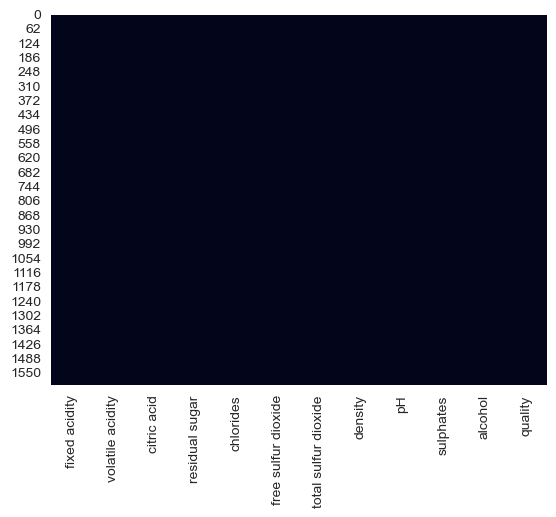

In [15]:
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False)

### Q3 데이터 분포 확인
각 변수의 데이터 분포가 어떠한지 기술하시오.(맨 위의 세개의 변수에 대해서만 기술)

1. 'fixed_acidity' :
2. 'volatile_acidity' :
3. 'citric_acid' :

1. fixed acidity : 
평균 약 8.32, 최솟값 4.6 ~ 최댓값 15.9로 넓게 분포하며, 
왜도(skewness)가 약 0.98로 오른쪽으로 치우친(right-skewed) 분포를 보인다. 
대부분의 값은 7~10 사이에 밀집되어 있다.

2. volatile acidity :
평균 약 0.53, 왜도 약 0.67로 완만하게 오른쪽으로 치우친 분포를 보이며, 
대부분 0.4~0.7 사이에 값이 몰려 있다.

3. citric acid :
평균 약 0.27, 최솟값이 0(즉, citric acid가 전혀 없는 와인이 다수 존재)이며, 
왜도 약 0.32로 세 변수 중 가장 대칭에 가까운 분포를 보이지만 
여전히 약간 오른쪽으로 치우쳐 있다.

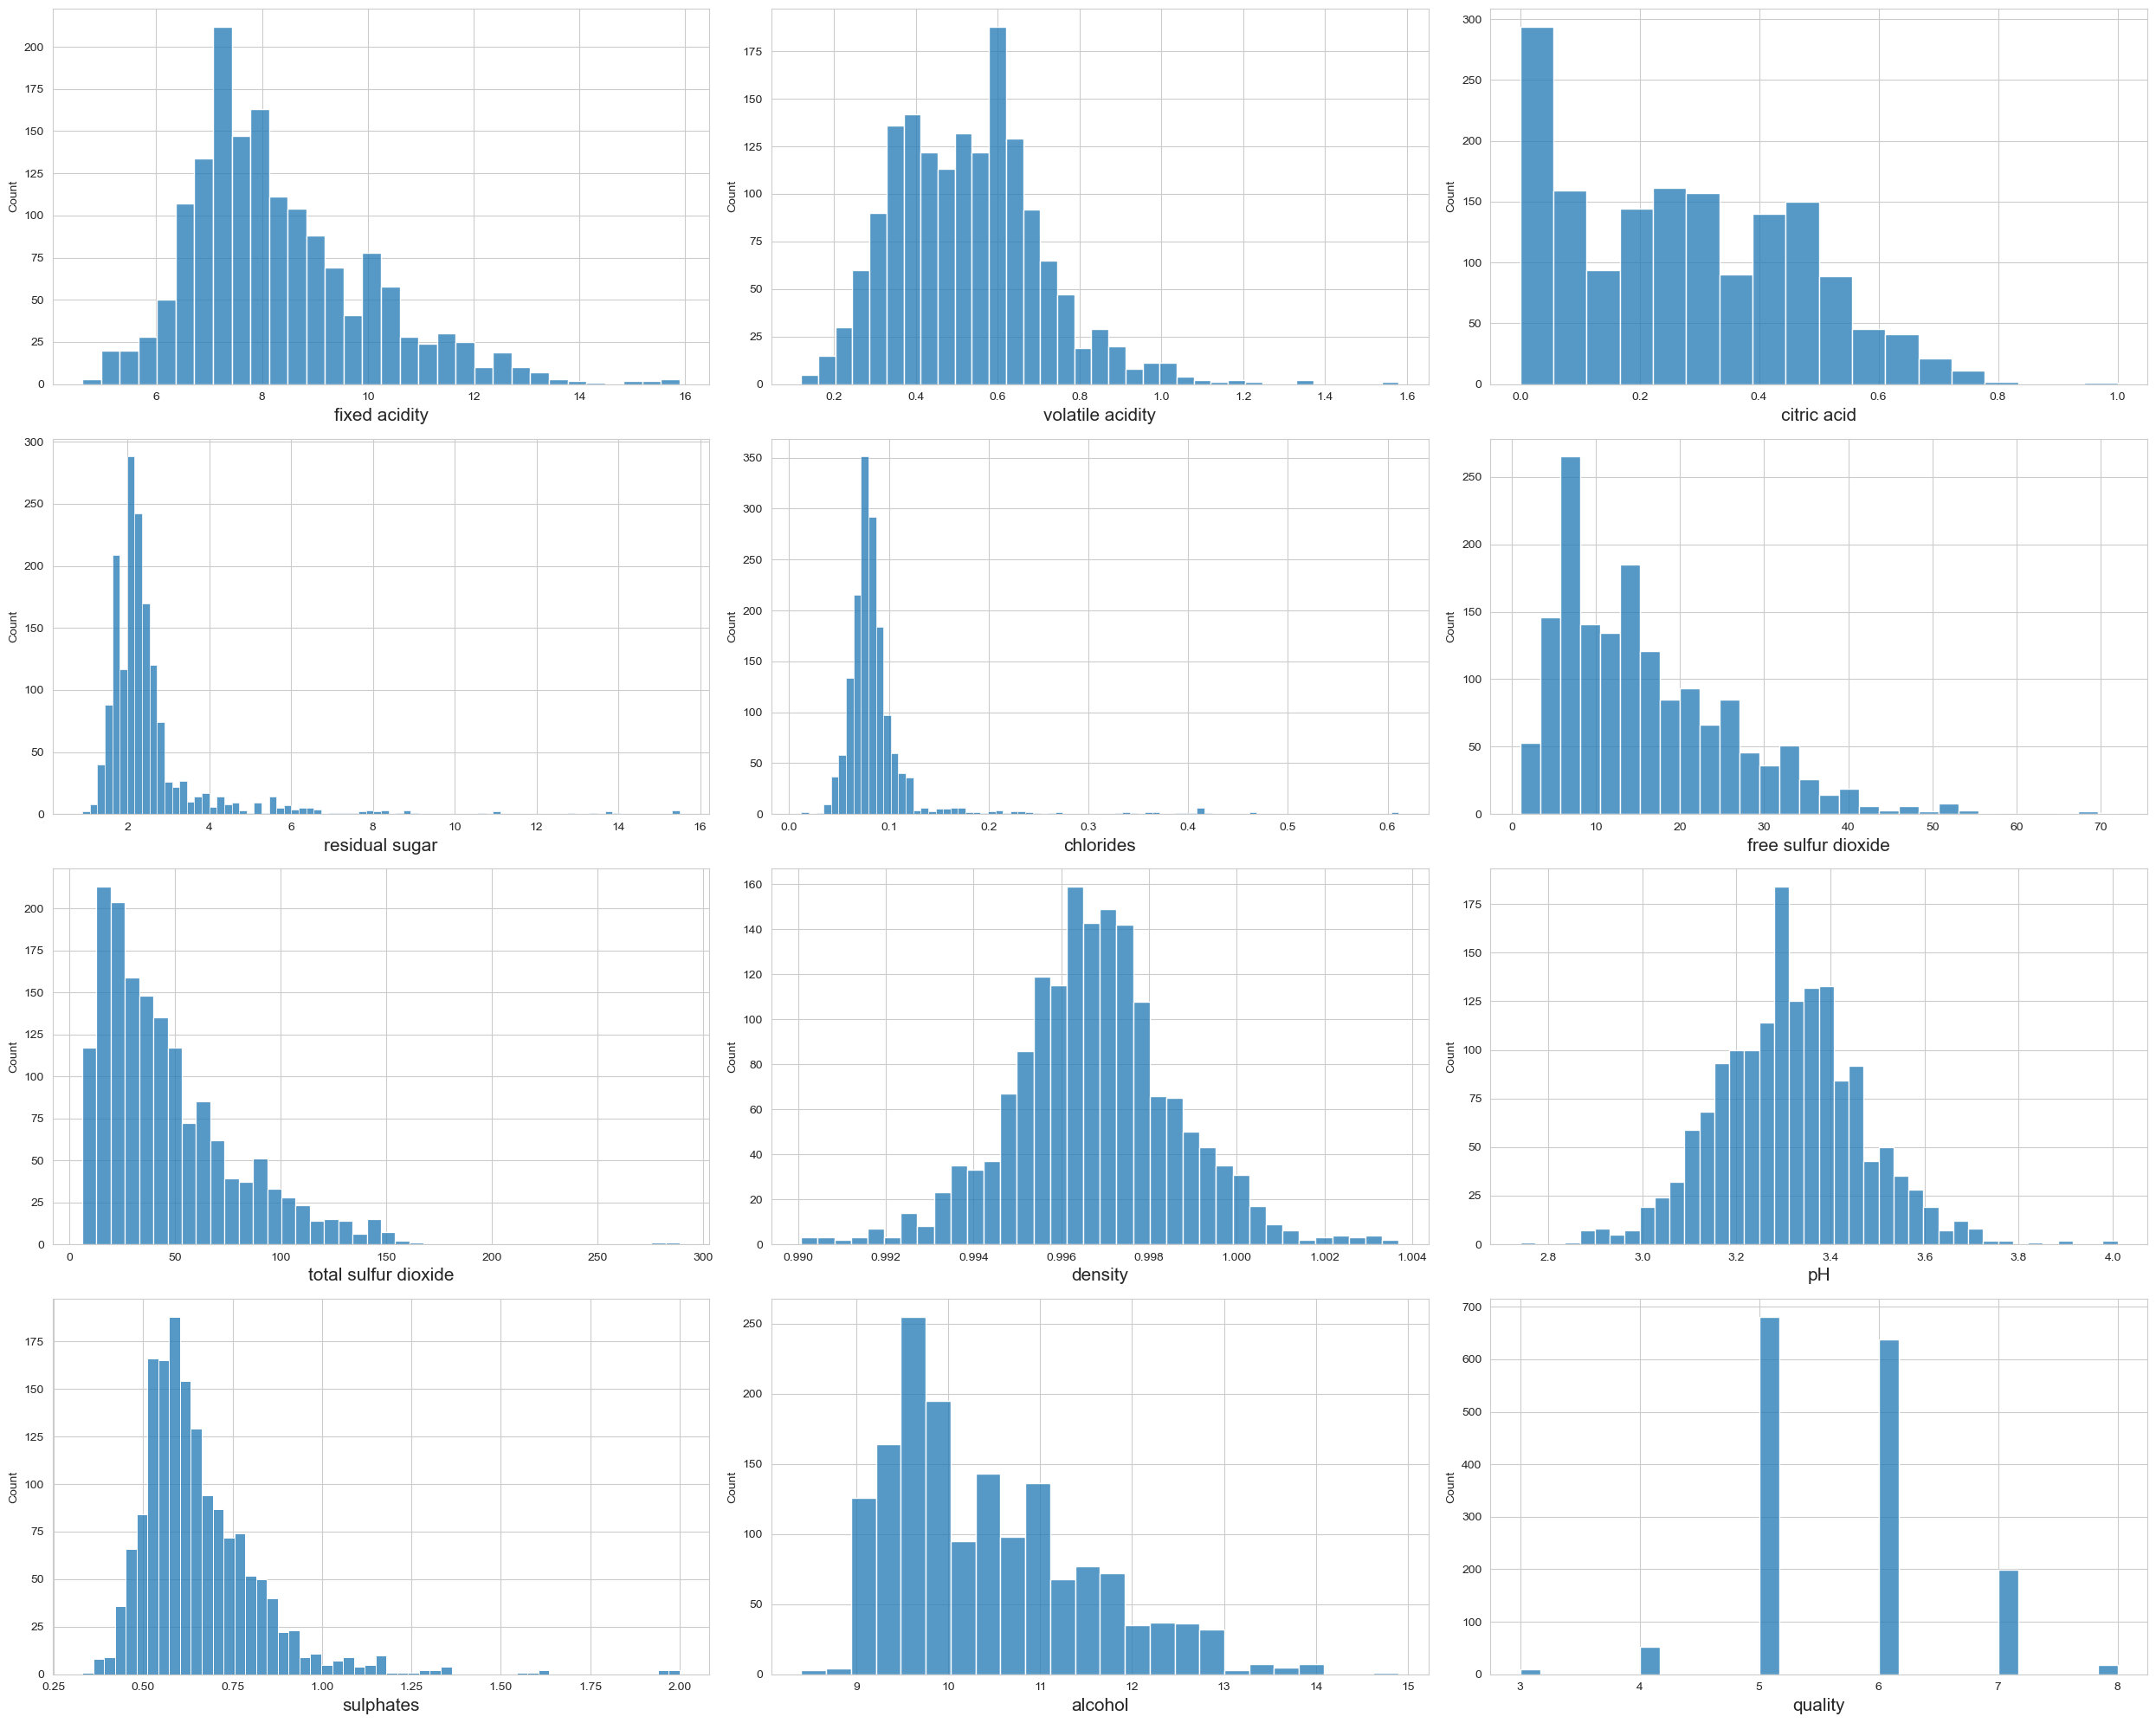

In [12]:
# let's see how data is distributed for every column
plt.figure(figsize = (25, 20))
plotnumber = 1

for col in df:
    if plotnumber <= 12:
        ax = plt.subplot(4, 3, plotnumber)
        sns.histplot(df[col])
        plt.xlabel(col, fontsize = 15)

    plotnumber += 1

plt.tight_layout()
plt.show()

### Q4. correlation plot을 그리고, 해당 plot에서 얻은 인사이트를 정리해보세요.

더불어 multicollinearity(통계학의 회귀분석에서 독립변수들 간에 강한 상관관계가 나타나는 문제)에 주목하여, 해당 correlation plot에서 어떤 영향을 주고 있는지 있는지 예를 들어 기술하시오.

답:



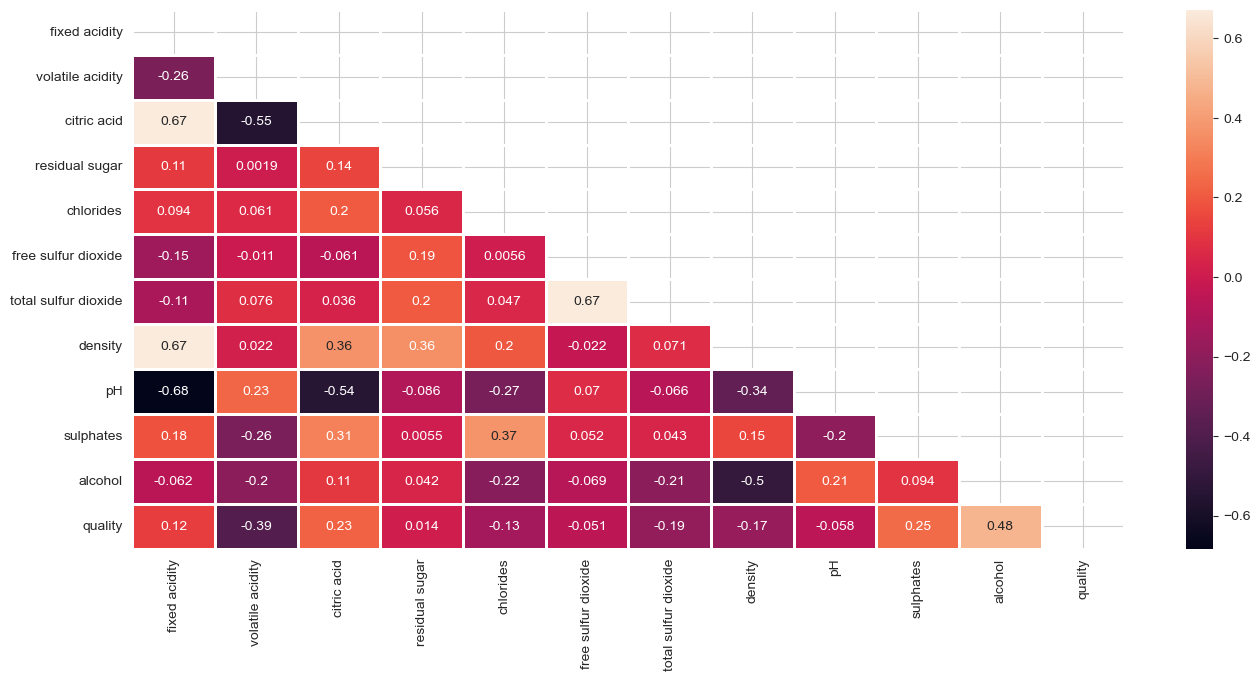

In [16]:
# 상관관계 plot
plt.figure(figsize = (16, 7))

corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype = bool))

sns.heatmap(corr, mask = mask, annot = True, fmt = '0.2g', linewidths = 1)
plt.show()

In [17]:
#Pearson correlation coefficient
import scipy.stats as st
print("Pearson correlation coefficient:", st.pearsonr(df["alcohol"],df["density"]))
print("Pearson correlation coefficient:", st.pearsonr(df["free sulfur dioxide"],df["total sulfur dioxide"]))
print("Pearson correlation coefficient:", st.pearsonr(df["fixed acidity"],df["pH"]))
print("Pearson correlation coefficient:", st.pearsonr(df["citric acid"],df["pH"]))
print("Pearson correlation coefficient:", st.pearsonr(df["fixed acidity"],df["density"]))

Pearson correlation coefficient: PearsonRResult(statistic=np.float64(-0.4961797702417016), pvalue=np.float64(3.9388353399881845e-100))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(0.6676664504810217), pvalue=np.float64(6.404722954680029e-207))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(-0.6829781945685314), pvalue=np.float64(4.063034039843752e-220))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(-0.5419041447395098), pvalue=np.float64(1.0072013259112185e-122))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(0.6680472921189736), pvalue=np.float64(3.0747470608605733e-207))


답: correlation heatmap을 확인한 결과, 다음과 같은 강한 상관관계가 관찰되었다.

- fixed acidity와 pH: -0.68 (강한 음의 상관) → 산도가 높을수록 pH(산성도 지표)는 낮아짐
- fixed acidity와 citric acid: 0.67 (강한 양의 상관)
- fixed acidity와 density: 0.67 (강한 양의 상관)
- free sulfur dioxide와 total sulfur dioxide: 0.67 (강한 양의 상관, 당연히 total이 free를 포함하는 개념이므로 자연스러운 결과)
- alcohol과 quality: 0.48 (양의 상관) → 도수가 높을수록 품질 평가가 높은 경향

특히 fixed acidity, citric acid, density, pH 네 변수가 서로 강하게 얽혀 있다는 점에서 
multicollinearity(다중공선성) 문제가 우려된다. 
예를 들어 회귀분석에 fixed acidity, citric acid, density, pH를 동시에 독립변수로 투입하면 
서로 정보가 중복되어 VIF(분산팽창계수)가 높아지고, 
개별 변수의 회귀계수 추정치가 불안정해지거나 해석이 어려워질 수 있다.
free sulfur dioxide와 total sulfur dioxide 역시 개념상 포함관계이므로 
동시에 모델에 넣을 경우 같은 문제가 발생할 수 있다.

### Q5. quality range를 두 파트로 나눠보세요.
In this dataset quality range is between 3 and 8
We will divide quality range into two parts:



*   High quality wine: 6 - 8
*   Low quality wine: 3 - 5



In [18]:
df["quality"] = df["quality"].apply(lambda x: 1 if x >= 6 else 0)

df["quality"]

0       0
1       0
2       0
3       1
4       0
       ..
1594    0
1595    1
1596    1
1597    0
1598    1
Name: quality, Length: 1599, dtype: int64

quality 값은 원래 3~8 범위의 정수형 점수였으나, 이를 이진 분류 문제로 다루기 위해 
두 그룹으로 나누었다.
- High quality wine (품질 6~8) → 1로 인코딩
- Low quality wine (품질 3~5) → 0으로 인코딩

이렇게 이진화하면 quality를 회귀(regression) 문제가 아닌 
classification(분류) 문제로 다룰 수 있게 되며, 
뒤에서 다루는 KNN, Logistic Regression 등 분류 모델에 바로 적용할 수 있다.

In [19]:
df.head().style.background_gradient(cmap = "Reds")

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,0
1,7.800000,0.880000,0.000000,2.600000,0.098000,25.000000,67.000000,0.996800,3.200000,0.680000,9.800000,0
2,7.800000,0.760000,0.040000,2.300000,0.092000,15.000000,54.000000,0.997000,3.260000,0.650000,9.800000,0
3,11.200000,0.280000,0.560000,1.900000,0.075000,17.000000,60.000000,0.998000,3.160000,0.580000,9.800000,1
4,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,0


### Q6. 종속변수(y,label)은 무엇이 되어야 하나요?


답: 종속변수(y, label)는 'quality'가 되어야 한다. 
이 데이터의 목적은 와인의 여러 화학적 특성(fixed acidity, volatile acidity, alcohol 등)을 
독립변수(x)로 사용하여, 와인의 품질(quality)이 High(1)인지 Low(0)인지를 
예측(classification)하는 것이기 때문이다.

In [21]:
# we select dependent variable (label)
y = df["quality"] #예측하려는 대상(종속변수/타겟) — High(1)/Low(0)

# we select independent variable
x = df.drop("quality", axis=1)  #열(column) 기준으로 quality변수를 제외한 나머지 11개 변수가 x(독립변수)가 됨

In [22]:
# splitting data into training and test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size = 0.25,
                                                    shuffle = True,
                                                    random_state = 1)

### Q7. 왜 Standardization(StandardScaler, MinMaxScaler 등) 사용할까요? 
두 Scaler의 특징에 대해 조사하고, 보다 적절한 Scaler가 무엇일지 그 이유와 함께 적어주세요.

답 :답:

[왜 Standardization(스케일링)이 필요한가]
현재 데이터셋의 변수들은 단위와 범위가 제각각이다. 예를 들어 total sulfur dioxide는 
6~289 범위인 반면, citric acid는 0~1 범위다. 이렇게 스케일 차이가 크면, 
특히 KNN처럼 거리(distance) 기반으로 작동하는 모델에서는 값의 범위가 큰 변수가 
실제 중요도와 상관없이 거리 계산을 지배해버리는 문제가 생긴다. 
따라서 모든 변수를 동일한 스케일로 맞춰줘야 각 변수가 공정하게 반영된다.

[StandardScaler]
- 평균을 0, 표준편차를 1로 맞추는 표준화(Z-score normalization) 방식
- 공식: (x - 평균) / 표준편차
- 이상치(outlier)의 영향을 상대적으로 덜 받으며, 
  정규분포에 가까운 데이터나 회귀/거리 기반 모델(선형회귀, SVM 등)에 자주 쓰임
- 값의 범위가 고정되지 않음 (음수 포함 가능)

[MinMaxScaler]
- 데이터를 최솟값 0, 최댓값 1 사이로 압축하는 정규화(Normalization) 방식
- 공식: (x - min) / (max - min)
- 값의 범위가 명확히 0~1로 고정되어 해석이 직관적이지만, 
  이상치에 민감하다는 단점이 있음 (극단값 하나가 스케일 전체를 왜곡시킬 수 있음)

[더 적절한 Scaler 선택]
이 데이터셋은 KNN처럼 거리 기반 알고리즘을 사용하고, 뒤에서 사용할 코드도 
feature_range=(0,1)로 명시되어 있으므로 MinMaxScaler가 적합하다. 
MinMaxScaler는 모든 변수를 동일한 범위(0~1)로 맞춰 KNN의 거리 계산에서 
특정 변수가 과도하게 영향을 주는 것을 방지한다. 
다만 이 데이터에 이상치(예: total sulfur dioxide, residual sugar 등에서 관찰되는 극단값)가 
많다는 점을 고려하면, 실무에서는 StandardScaler나 이상치 제거 후 
MinMaxScaler를 적용하는 방식도 함께 고려할 수 있다.

In [24]:
# scaling data
from sklearn.preprocessing import MinMaxScaler

norm = MinMaxScaler(feature_range = (0, 1))
norm.fit(x_train)
x_train = norm.transform(x_train)
x_test = norm.transform(x_test)

### Q7-2. 위의 코드에서, train dataset에 대해서는 fit_transform을, test dataset에 대해서는 transform을 실시하는 이유가 무엇일지 조사해주세요.
답 :답:

fit()은 스케일링에 필요한 통계값(MinMaxScaler의 경우 각 변수의 최솟값·최댓값, StandardScaler의 경우 평균·표준편차)을 데이터로부터 "학습"하는 과정이고, 
transform()은 그 학습된 통계값을 이용해 실제로 데이터를 변환하는 과정이다.

train set에는 fit_transform() (= fit + transform)을 적용해, 
스케일링 기준을 오직 train 데이터로부터만 계산하고 그 기준으로 train 데이터를 변환한다.

test set에는 fit() 없이 transform()만 적용해, 
train에서 이미 학습된 동일한 기준(최솟값/최댓값 또는 평균/표준편차)을 그대로 사용해 변환한다.

만약 test set에도 fit()을 다시 적용하면, test 데이터의 통계 정보(최솟값, 최댓값 등)가 
스케일링 기준에 새로 반영되어버린다. 이는 모델이 학습 단계에서 절대 봐서는 안 되는 
test set 정보가 간접적으로 섞이는 data leakage(데이터 누수)에 해당한다. 
그 결과 모델의 test 성능이 실제보다 과대평가(overestimate)되고, 
실제 운영 환경(unseen data)에서는 성능이 떨어지는 문제가 발생할 수 있다.

따라서 "train 기준으로 학습하고, test는 그 기준을 그대로 적용받는 것"이 필요한 머신러닝 워크플로우이다.

In [ ]:
print(x_train[0:5])
print("\n")
print(x_train.shape)
print("_________________________________________________________________________")
print(x_test[0:5])
print("\n")
print(x_test.shape)

[[0.23893805 0.1369863  0.23       0.10769231 0.090301   0.47887324
  0.23529412 0.4441896  0.54330709 0.17365269 0.26153846]
 [0.32743363 0.38013699 0.26       0.09230769 0.12040134 0.14084507
  0.13602941 0.57568807 0.4488189  0.11976048 0.12307692]
 [0.69911504 0.17808219 0.6        0.13076923 0.11538462 0.42253521
  0.24264706 0.72859327 0.28346457 0.23952096 0.32307692]
 [0.36283186 0.44178082 0.22       0.10769231 0.08695652 0.11267606
  0.13235294 0.47629969 0.28346457 0.13173653 0.15384615]
 [0.32743363 0.49657534 0.01       0.1        0.09698997 0.05633803
  0.02941176 0.50688073 0.45669291 0.1497006  0.4       ]]


(1199, 11)
_________________________________________________________________________
[[0.37168142 0.19863014 0.64       0.1        0.13545151 0.11267606
  0.13235294 0.65214067 0.62992126 0.19760479 0.32307692]
 [0.36283186 0.34931507 0.28       0.13846154 0.14046823 0.22535211
  0.23161765 0.5558104  0.40944882 0.17964072 0.27692308]
 [0.51327434 0.15068493 0.58  

In [ ]:
print(y_train.head())
print(y_train.shape)
print("___________________________")
print(y_test.head())
print(y_test.shape)

1144    0
73      0
446     0
399     0
647     0
Name: quality, dtype: int64
(1199,)
___________________________
75      0
1283    1
408     1
1281    1
1118    1
Name: quality, dtype: int64
(400,)


### Q8. Building Classification models

이번 코드에서는 non parametric model; knn을 사용하여 train, test 진행해보았습니다.

아래의 코드 외에도 원하는 한가지 classification 모델(KNN 제외)을 선정하여 아래의 과정을 반복하고, 그 결과를 해석하세요. grid search 과정은 거치지 않고 임의의 파라미터값으로 진행해도 좋습니다.

아래와 같은 Kaggle 코드들도 참고해보세요.  
- https://www.kaggle.com/code/melissamonfared/red-wine-quality-prediction-eda-classification/notebook
- https://www.kaggle.com/code/eisgandar/red-wine-quality-eda-classification


In [ ]:
## 아래의 과정을 반복하시오.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
#KNN

knn = KNeighborsClassifier()

knn_params = {"n_neighbors": np.arange(2, 50),
             "weights": ["uniform", "distance"],
             "leaf_size": [25, 30, 25]}

knn_cv_model = GridSearchCV(knn, knn_params, cv = 10)
knn_cv_model.fit(x_train, y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'leaf_size': [25, 30, 25],
                         'n_neighbors': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),
                         'weights': ['uniform', 'distance']})

In [ ]:
print("Best score for train set: " + str(knn_cv_model.best_score_))

print("____________________________________________")

print("best K value: " + str(knn_cv_model.best_params_["n_neighbors"]),
     "\nbest weights: " + knn_cv_model.best_params_["weights"],
     "\nbest leaf size: " + str(knn_cv_model.best_params_["leaf_size"]))

Best score for train set: 0.798172268907563
____________________________________________
best K value: 21 
best weights: distance 
best leaf size: 25


In [ ]:
knn_model = KNeighborsClassifier(n_neighbors = knn_cv_model.best_params_["n_neighbors"],
                                leaf_size = knn_cv_model.best_params_["leaf_size"],
                                weights = knn_cv_model.best_params_["weights"])

knn_model.fit(x_train, y_train)

KNeighborsClassifier(leaf_size=25, n_neighbors=21, weights='distance')

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = knn_model.predict(x_test)
print("Accuracy:",accuracy_score(y_test, y_pred)) #Validation Set Accurac

Accuracy: 0.8025


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.81      0.79       188
           1       0.82      0.80      0.81       212

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400



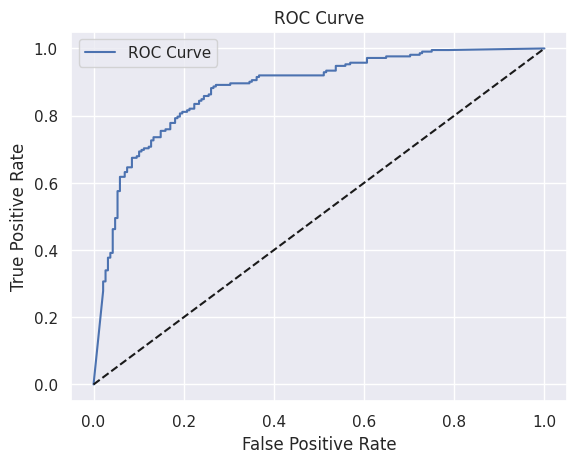

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
# Validation Set 에 대한 예측확률 계산
y_prob = knn_model.predict_proba(x_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label = "ROC Curve")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [25]:
from sklearn.linear_model import LogisticRegression

# 모델 정의 및 학습
log_model = LogisticRegression(max_iter=1000, random_state=1)
log_model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
from sklearn.metrics import accuracy_score

y_pred_log = log_model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_log))

Accuracy: 0.7375


In [27]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.71      0.76      0.73       188
           1       0.77      0.72      0.74       212

    accuracy                           0.74       400
   macro avg       0.74      0.74      0.74       400
weighted avg       0.74      0.74      0.74       400



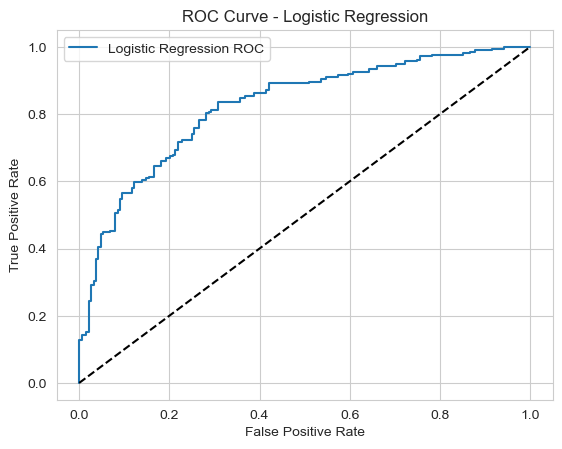

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_log = log_model.predict_proba(x_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)
plt.plot(fpr, tpr, label = "Logistic Regression ROC")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

LogisticRegression(max_iter=1000, random_state=1) : 로지스틱 회귀 모델 생성.
max_iter는 최적화 반복 횟수 상한(수렴 안 될 때 늘려줌), random_state는 재현성 고정
.fit(x_train, y_train) : train 데이터로 모델 학습
.predict(x_test) : test 데이터에 대해 0/1 예측값 산출
accuracy_score : 전체 예측 중 맞춘 비율
classification_report : precision, recall, f1-score를 클래스별로 보여줌
predict_proba(x_test)[:,1] : 각 샘플이 클래스 1(High quality)일 확률 (ROC curve 그리려면 확률값 필요)
roc_curve : threshold를 바꿔가며 FPR(위양성률)/TPR(재현율) 계산
plt.plot([0,1],[0,1],'k--') : 랜덤 예측 기준선(대각선) 표시용

KNN은 비모수(non-parametric) 모델로 데이터 포인트 간 거리를 기반으로 국소적(local) 결정경계를 형성하는 반면, 
Logistic Regression은 선형 결정경계를 가정하는 모수적(parametric) 모델이다.
두 모델의 accuracy와 ROC-AUC를 비교하면, 만약 Logistic Regression의 성능이 
KNN과 비슷하거나 더 높다면 이 데이터의 클래스 구분이 비교적 선형적으로 
분리 가능하다는 것을 시사하고, 반대로 KNN이 더 우수하다면 
비선형적인 패턴이 존재할 가능성이 높다는 것을 의미한다.
또한 Logistic Regression은 계수(coefficient)를 통해 각 변수가 
quality에 미치는 영향의 방향과 크기를 해석할 수 있다는 장점이 있어, 
KNN보다 설명력(interpretability) 측면에서 유리하다.